In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import modularity

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.cluster.hierarchy import fcluster, linkage, dendrogram, cut_tree, leaves_list
from scipy.spatial.distance import pdist, squareform

In [74]:
%run LittRuP__import_functions.ipynb

In [75]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [50]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [51]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [52]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [53]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Préalable : Jaccard et clustering**<br>
**=> réorganisation des thèmes**<br>
**de la matrice des thèmes**<br>
**de la matrice des co-occurrence**

In [54]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 65 thèmes => [65 x (65-1)]/2 paires (=2080)

MT = matrix_themes.T.to_numpy().astype(bool)

dist_jaccard_T = pdist(
    MT, 
    metric="jaccard"
)

# linkage sur matrice de Jaccard

LT = linkage(
    dist_jaccard_T, 
    method="average"
)

# ordre des thèmes selon le linkage

ordered_idx = leaves_list(LT)
reordered_idx = np.flip(ordered_idx)
theme_names_reordered = np.array(the_themes)[reordered_idx]

matrix_themes_reordered = matrix_themes.loc[:, theme_names_reordered]

# matrice des co-occurrences réordonnée

matrix_co_occurrence = matrix_themes_reordered.T @ matrix_themes_reordered


**Représentation des thèmes en réseau (par co-occurrence)**

In [55]:
def construire_graphe(mat, seuil):

    G = nx.Graph()

    for i in mat.index:
        for j in mat.columns:

            poids = mat.loc[i, j]

            if i != j and poids >= seuil:
                G.add_edge(i, j, weight=poids)

    return G

In [26]:
# Construction du graphe

seuil = 5
G5 = construire_graphe(matrix_co_occurrence, seuil=seuil)

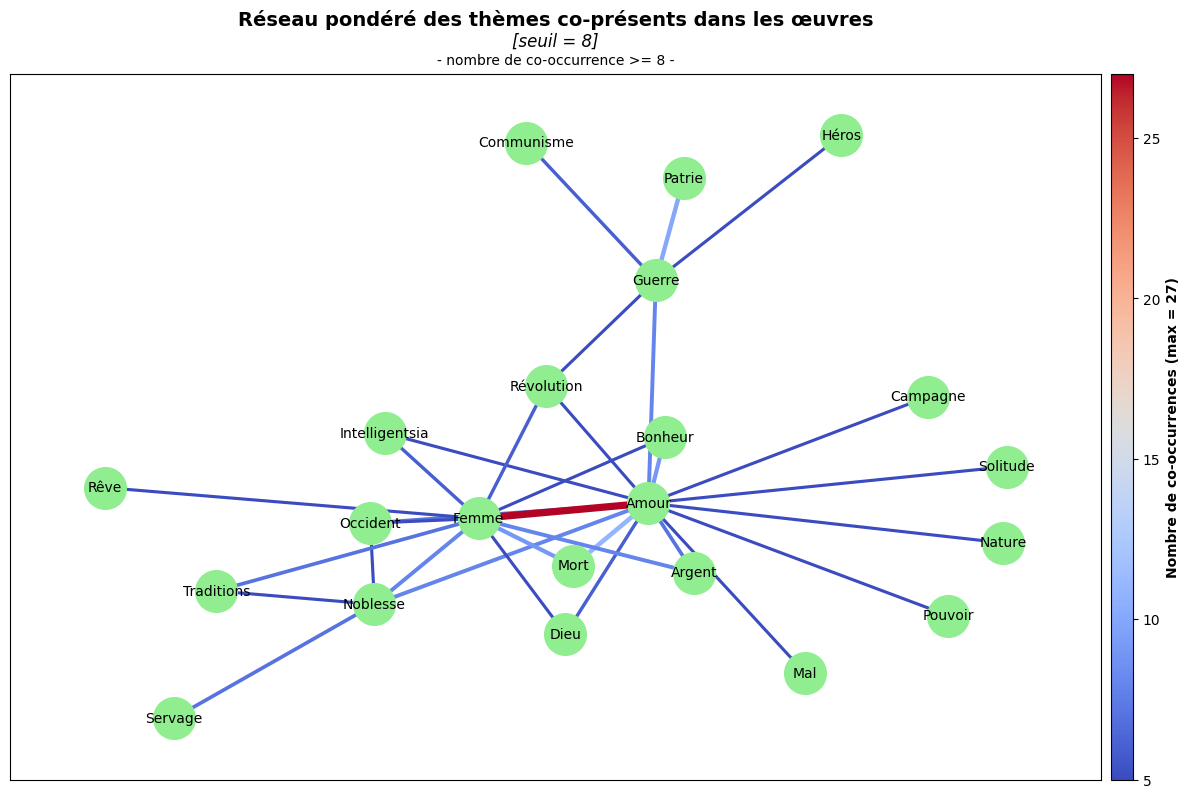

In [56]:

fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(G5, seed=1949)

# poids des arêtes
weights = np.array([
    G5[u][v]["weight"]
    for u, v in G5.edges()
])

# épaisseur
widths = np.sqrt(weights)

# dessin
edges = nx.draw_networkx_edges(
    G5,
    pos,
    ax=ax,
    width=widths,
    edge_color=weights,
    edge_cmap=plt.cm.coolwarm
)

# noeuds
nx.draw_networkx_nodes(
    G5,
    pos,
    ax=ax,
    node_color="lightgreen",
    node_size=900
)

# labels
nx.draw_networkx_labels(
    G5,
    pos,
    ax=ax,
    font_size=10
)

# barre de couleurs
im = ax.collections[0]

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="2%",   # largeur de la colorbar
    pad=0.10     # distance au graphique
)

cbar = fig.colorbar(
    im,
    cax=cax,
    ticks=np.arange(min_val, max_couple+4, 5),
#    extend="min"
)
cbar.set_label(f"Nombre de co-occurrences (max = {max_couple})", fontsize=10, fontweight="bold")
cbar.ax.tick_params(labelsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Réseau pondéré des thèmes co-présents dans les œuvres", y1=35,
    t2=f"[seuil = {seuil}]", y2=20,
    t3=f"- nombre de co-occurrence >= {seuil} -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_réseau_coprésence_avec_seuil_5.png", 
    dpi=300, 
    bbox_inches="tight")

plt.show()

**Analyse de sensibilité par divers seuils**

In [57]:
# résultats numériques

resultats = []

communautes_par_seuil = {}

for seuil in [3, 4, 5, 6, 7, 8]:
    
    G_seuil = construire_graphe(matrix_co_occurrence, seuil=seuil)
    
    # Facultatif mais utile :
    # on enlève les thèmes isolés, c'est-à-dire sans aucune arête
    G_actif = G_seuil.copy()
    G_actif.remove_nodes_from(list(nx.isolates(G_actif)))
    
    if G_actif.number_of_edges() > 0:
        
        communautes = greedy_modularity_communities(
            G_actif,
            weight="weight"
        )
        
        Q = modularity(
            G_actif,
            communautes,
            weight="weight"
        )
        
        nb_communautes = len(communautes)
        
    else:
        communautes = []
        Q = None
        nb_communautes = 0
    
    communautes_par_seuil[seuil] = communautes
    
    resultats.append({
        "seuil": seuil,
        "nombre de noeuds actifs": G_actif.number_of_nodes(),
        "nombre d'arêtes": G_actif.number_of_edges(),
        "nombre de communautés": nb_communautes,
        "modularité": Q
    })

df_sensibilite = pd.DataFrame(resultats)

In [58]:
# présentation des résultats numériques

df_sensibilite_affichage = df_sensibilite.copy()

df_sensibilite_affichage = df_sensibilite_affichage.rename(columns={
    "nombre de noeuds actifs": "nombre de\nnœuds actifs",
    "nombre d'arêtes": "nombre\nd'arêtes",
    "nombre de communautés": "nombre de\ncommunautés"
})

df_sensibilite_affichage.style.format({
    "modularité": "{:.3f}"
}).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("white-space", "pre-line"),
            ("text-align", "center")
        ]
    }
])


,seuil,nombre de nœuds actifs,nombre d'arêtes,nombre de communautés,modularité
0,3,51,107,6,0.291
1,4,34,57,6,0.262
2,5,22,32,3,0.237
3,6,15,17,3,0.224
4,7,11,13,3,0.190
5,8,8,9,2,0.163


**liste des communautés dans chaque cas**

In [76]:
for seuil in [3, 4, 5, 6, 7, 8]:
    
    print("\n" + "=" * 60)
    print("Seuil =", seuil)
    print("=" * 60)
    
    communautes = communautes_par_seuil[seuil]
    
    for numero, communaute in enumerate(communautes, start=1):
        
        themes_communaute = sorted(list(communaute))
        
        print(f"\nCommunauté {numero} :")
        print(themes_communaute)


Seuil = 3

Communauté 1 :
['Amour', 'Bonheur', 'Campagne', 'Délire-Folie', 'Ennui', 'Femme', 'Individu', 'Intelligentsia', 'Justice', 'Mal', 'Mariage', 'Misère', 'Occident', 'Paysans', 'Peuple', 'Province', 'Russie', 'Révolution', 'Rêve', 'Socialisme', 'Violence']

Communauté 2 :
['Art', 'Camps', 'Capitalisme', 'Liberté', 'Médiocrité', 'Société', 'Souffrance', 'Travail']

Communauté 3 :
['Apprentissage', 'Fonctionnaires', 'Nature', 'Noblesse', 'Religion', 'Servage', 'Traditions']

Communauté 4 :
['Argent', 'Dieu', 'Humanisme', 'Marchands', 'Mort', 'Solitude']

Communauté 5 :
['Communisme', 'Guerre', 'Héros', 'Patrie', 'Responsabilité']

Communauté 6 :
['Fantastique', 'Pouvoir', 'Remords', 'Ville']

Seuil = 4

Communauté 1 :
['Amour', 'Apprentissage', 'Argent', 'Bonheur', 'Campagne', 'Dieu', 'Ennui', 'Femme', 'Humanisme', 'Individu', 'Mal', 'Mort', 'Nature', 'Peuple', 'Rêve', 'Solitude']

Communauté 2 :
['Communisme', 'Guerre', 'Héros', 'Intelligentsia', 'Patrie', 'Responsabilité', 'Ré

**créer un dictionnaire des communautés**

In [93]:
def dataframe_communautes(G):
    
    communities = nx.algorithms.community.greedy_modularity_communities(
        G,
        weight="weight"
    )
    
    community_df = pd.DataFrame({
        (f"communauté_{i}", "thèmes"): pd.Series(sorted(community))
        for i, community in enumerate(communities, start=1)
    }).fillna("")
    
    return community_df

**constituer le dictionnaire avec les différents seuils**

In [94]:

seuils = [3, 4, 5, 6, 7, 8]

df_communautes_par_seuil = {}

for seuil in seuils:
    
    G_seuil = construire_graphe(
        matrix_co_occurrence,
        seuil=seuil
    )
    
    df_communautes = dataframe_communautes(G_seuil)
    
    # ajout d'un niveau supérieur dans les colonnes
    df_communautes = pd.concat(
        {f"seuil = {seuil}": df_communautes},
        axis=1
    )
    
    df_communautes_par_seuil[seuil] = df_communautes

**exporter tous les df_communautes dans un seul fichier Excel**

In [95]:

fichier_excel = DAT_DIR / "LittRu_communautes_par_seuil.xlsx"

with pd.ExcelWriter(fichier_excel) as writer:
    
    for seuil in seuils:
        
        df_communautes_par_seuil[seuil].to_excel(
            writer,
            sheet_name=f"seuil_{seuil}"
        )

print(f"Fichier enregistré dans : {fichier_excel}")

Fichier enregistré dans : C:\Users\thaly\OneDrive\Documents\_Post-Bac-Python\Programs (LittRu - Publication 01.07.2026)\Data\LittRu_communautes_par_seuil.xlsx


In [96]:
# exemple pour seuil = 5

df_communautes_par_seuil[5]

seuil = 5                          
      communauté_1 communauté_2 communauté_3
            thèmes       thèmes       thèmes
0            Amour   Communisme     Noblesse
1           Argent       Guerre     Occident
2          Bonheur        Héros      Servage
3         Campagne       Patrie   Traditions
4             Dieu   Révolution             
5            Femme                          
6   Intelligentsia                          
7              Mal                          
8             Mort                          
9           Nature                          
10         Pouvoir                          
11            Rêve                          
12        Solitude

**Mesures pour seuil = 5**

In [81]:
# créer chaque mesure sous forme de Series, puis les joindre par thème

communities = nx.algorithms.community.greedy_modularity_communities(
    G5,
    weight="weight"
)

theme_community = {}

for i, community in enumerate(communities, start=1):
    for theme in community:
        theme_community[theme] = i

community = pd.Series(
    theme_community,
    name="Community"
)

weighted_degree = pd.Series(
    dict(G5.degree(weight="weight")),
    name="Weighted_degree"
)

eigenvector = pd.Series(
    nx.eigenvector_centrality(G5, weight="weight"),
    name="Eigenvector"
)

network_measures_df = pd.concat(
    [
        weighted_degree,
        eigenvector,
        community
    ],
    axis=1
)

network_measures_df = (
    network_measures_df
    .reset_index()
    .rename(columns={"index": "Theme"})
    .sort_values(["Community", "Weighted_degree"], ascending=[True, False])
    .reset_index(drop=True)
)

network_measures_df

,Theme,Weighted_degree,Eigenvector,Community
0,Amour,118,0.601991,1
1,Femme,91,0.565335,1
2,Mort,20,0.245911,1
3,Argent,15,0.183472,1
4,Bonheur,14,0.173139,1
5,Dieu,11,0.135213,1
6,Intelligentsia,11,0.134443,1
7,Nature,5,0.063209,1
8,Campagne,5,0.063209,1
9,Pouvoir,5,0.063209,1


In [82]:
# Autres variables possibles, mais betweenness et closeness 
# demandent une réflexion sur la transformation des poids en distances.

weighted_degree = pd.Series(
    dict(G5.degree(weight="weight")),
    name="Weighted_degree"
)

degree_centrality = pd.Series(
    nx.degree_centrality(G5),
    name="Degree_centrality"
)

betweenness_centrality = pd.Series(
    nx.betweenness_centrality(G5, weight="weight"),
    name="Betweenness_centrality"
)

closeness = pd.Series(
    nx.closeness_centrality(G5),
    name="Closeness"
)

eigenvector = pd.Series(
    nx.eigenvector_centrality(G5, weight="weight"),
    name="Eigenvector"
)

communities = nx.algorithms.community.greedy_modularity_communities(
    G5,
    weight="weight"
)

theme_community = {}

for i, community in enumerate(communities, start=1):
    for theme in community:
        theme_community[theme] = i

community = pd.Series(
    theme_community,
    name="Community"
)

network_measures_df = pd.concat(
    [
        weighted_degree,
        degree_centrality,
        betweenness_centrality,
        closeness,
        eigenvector,
        community
    ],
    axis=1
)

network_measures_df = (
    network_measures_df
    .reset_index()
    .rename(columns={"index": "Theme"})
    .sort_values(["Community", "Weighted_degree"], ascending=[True, False])
    .reset_index(drop=True)
)

network_measures_df

,Theme,Weighted_degree,Degree_centrality,Betweenness_centrality,Closeness,Eigenvector,Community
0,Amour,118,0.714286,0.611905,0.777778,0.601991,1
1,Femme,91,0.523810,0.269048,0.617647,0.565335,1
2,Mort,20,0.095238,0.000000,0.477273,0.245911,1
3,Argent,15,0.095238,0.000000,0.477273,0.183472,1
4,Bonheur,14,0.095238,0.000000,0.477273,0.173139,1
5,Dieu,11,0.095238,0.019048,0.477273,0.135213,1
6,Intelligentsia,11,0.095238,0.019048,0.477273,0.134443,1
7,Nature,5,0.047619,0.000000,0.446809,0.063209,1
8,Campagne,5,0.047619,0.000000,0.446809,0.063209,1
9,Pouvoir,5,0.047619,0.000000,0.446809,0.063209,1


In [83]:
# calculer la modularité finale obtenue par NetworkX :

communities = nx.algorithms.community.greedy_modularity_communities(
    G5,
    weight="weight"
)

Q = nx.algorithms.community.modularity(
    G5,
    communities,
    weight="weight"
)

print(Q)

0.2370271604938272
